## Double Homograohy On Chess Board

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import math
from sklearn.cluster import KMeans
import numpy as np
from sklearn.cluster import DBSCAN
import itertools


### Preprocessing Image

In [35]:

def resize_image(img, max_width=1024):
    """
    Resizes image to a maximum width of 10024 pixels, maintaining aspect ratio.
    """
    h, w = img.shape[:2]
    if w > max_width:
        scale = max_width / float(w)
        return cv2.resize(img, (int(w*scale), int(h*scale)))
    return img

def show_image_debug(title, img, points=None, Hlines=None, Vlines=None, treat_lines_as_infinite=False, size=7):
    """
    Display an image during processing with optional overlays. 
    It now expects Hlines/Vlines to be in the robust (N, 4) format: [x1, y1, x2, y2].
    """
    display_img = img.copy()
    h, w = display_img.shape[:2]

    def draw_lines(lines, color, treat_infinite=False):
        if lines is None: return
        # Ensure lines is an N x 4 array and handle empty arrays
        lines = np.atleast_2d(lines) 
        if lines.size == 0: return
            
        for line in lines:
            x1, y1, x2, y2 = line.astype(int) 
            if treat_infinite:
                if abs(x2 - x1) < 1:
                    cv2.line(display_img, (x1, 0), (x1, h), color, 2)
                    continue
                slope = (y2 - y1) / (x2 - x1)
                intercept = y1 - slope * x1
                if abs(y2 - y1) < 1:
                    cv2.line(display_img, (0, y1), (w, y1), color, 2)
                    continue
                y_start = int(slope * 0 + intercept)
                y_end = int(slope * w + intercept)
                cv2.line(display_img, (0, y_start), (w, y_end), color, 2)
            else:
                cv2.line(display_img, (x1, y1), (x2, y2), color, 2)

    draw_lines(Hlines, (0, 255, 0), treat_lines_as_infinite)
    
    draw_lines(Vlines, (255, 0, 0), treat_lines_as_infinite)
    
    
    plt.figure(figsize=(size, size))

    if len(display_img.shape) == 3:
        plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(display_img, cmap='gray')
    if points is not None:
        pts = np.array(points)
        plt.scatter(pts[:, 0], pts[:, 1], c='red', s=30)

    plt.title(title)
    plt.axis('off')
    plt.show()

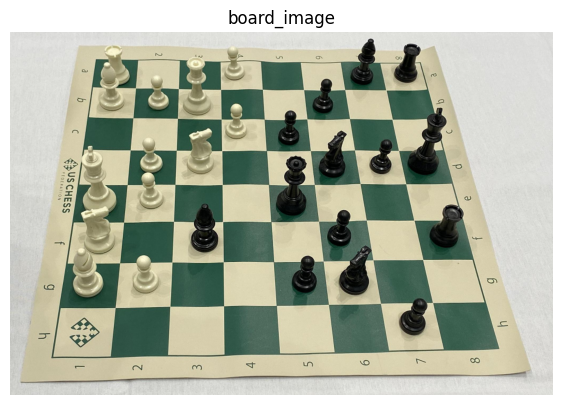

In [36]:

src_path = 'boards/test3.jpg'
#reading image
image = cv2.imread(src_path)
#resozing for max length
image = resize_image(image)
#display image
show_image_debug("board_image", image)

In [37]:


def pre_processing_pipeline(img, threshold1=50, threshold2=70, dil_iter=1):
    #applying grayscale
    output = img.copy()
    if len(img.shape) == 3: output = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #applying gaussian blur
    output = cv2.GaussianBlur(output, (5, 5), 0)
    #canny edge detector
    #process = cv2.Canny(process, 50, 70)
    output = cv2.Canny(output, threshold1, threshold2)
    #dilation
    output = cv2.dilate(output, None, iterations=1) 

    return output


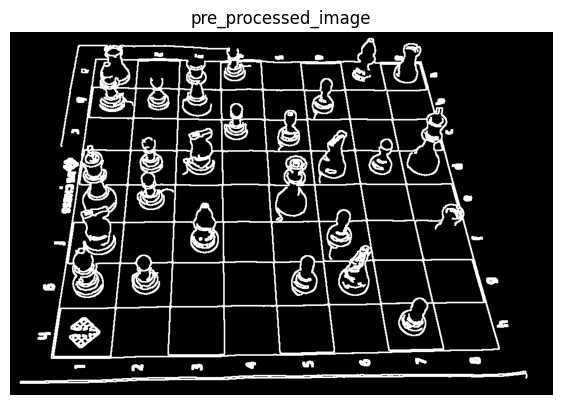

In [38]:
processes_image = pre_processing_pipeline(image, threshold1=10, threshold2=200)
show_image_debug("pre_processed_image", processes_image)

### Detecting Lines Image

In [39]:
def detect_lines(img, hough_threshold=50, min_line_length=50, max_line_gap=20):
    """
    Detects line segments using HoughLinesP and returns them in the 
    desired (N, 4) format: [x1, y1, x2, y2].
    """
    lines = cv2.HoughLinesP(
        img, 
        2, 
        np.pi/180, 
        threshold=hough_threshold, 
        minLineLength=min_line_length, 
        maxLineGap=max_line_gap
    )    
    if lines is not None:
        return lines.reshape(-1, 4)
    else:
        return np.array([], dtype=np.int32).reshape(0, 4)


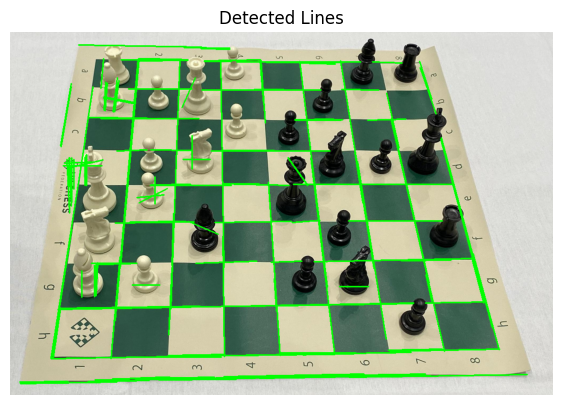

In [40]:
lines = detect_lines(processes_image, hough_threshold=100, min_line_length=50, max_line_gap=5)
show_image_debug("Detected Lines", image, Hlines=lines)

In [41]:
def visualize_dbscan_clusters(angles_deg, labels, title="DBSCAN Clustering of Line Angles"):
    """
    Creates a scatter plot of line angles colored by their DBSCAN cluster label.
    Args:
        angles_deg (np.array): 1D array of normalized line angles in degrees [0, 180).
        labels (np.array): 1D array of cluster labels assigned by DBSCAN.
        title (str): Title for the plot.
    """
    unique_labels = set(labels)
    n_clusters_ = len(unique_labels) - (1 if -1 in labels else 0)
    plt.figure(figsize=(10, 5))
    # Define color map for clusters
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    # Iterate over unique labels (-1 is noise)
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black used for noise.
            col = [0, 0, 0, 1]
            marker = 'x'
            s_size = 30
        else:
            marker = 'o'
            s_size = 50

        # Create a mask for the points belonging to the current cluster k
        class_member_mask = (labels == k)
        xy = angles_deg[class_member_mask]
        plt.scatter(xy, 
                    np.ones_like(xy),
                    marker=marker, 
                    s=s_size, 
                    c=[col], 
                    label=f'Cluster {k}' if k != -1 else 'Noise',
                    zorder=3
                   )
    plt.title(f'{title} (Estimated Clusters: {n_clusters_})')
    plt.xlabel('Normalized Line Angle (Degrees) [0° to 180°]')
    plt.yticks([]) # Remove Y-axis ticks since the plot is 1D
    plt.xlim(0, 180)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.legend(loc='upper right')
    plt.show()

In [42]:
def robust_chessboard_lines(lines, num_lines=4, angle_tolerance_deg=10, min_samples=3):
    """
    Clusters detected line segments into horizontal and vertical groups, 
    removes outliers using DBSCAN on angles, and selects the top 'num_lines' 
    based on line length.

    Args:
        num_lines (int): The number of top lines to select for each category.
        angle_tolerance_deg (float): The maximum angle difference (epsilon) for DBSCAN clustering, in degrees.
        min_samples (int): The minimum number of lines to form a cluster (DBSCAN).
    """
    if lines.shape[0] == 0: return np.array([]), np.array([])

    #get all dx dy
    dx = lines[:, 2] - lines[:, 0]
    dy = lines[:, 3] - lines[:, 1]
    # Calculate angles
    angles_rad = np.arctan2(dy, dx)
    angles_rad_normalized = angles_rad % np.pi
    angles_deg_normalized = np.degrees(angles_rad_normalized)
    X = angles_deg_normalized.reshape(-1, 1)
    # Calculate lengths
    lengths = np.sqrt(dx**2 + dy**2)
    
    # 2. Robust Clustering and Outlier Removal with DBSCAN    
    db = DBSCAN(eps=angle_tolerance_deg, min_samples=min_samples, metric='euclidean').fit(X)
    labels = db.labels_
    visualize_dbscan_clusters(angles_deg_normalized, labels)

    # Find the indices of the two largest clusters (Horizontal and Vertical)
    unique_labels = set(labels)
    cluster_labels = [l for l in unique_labels if l != -1] # Exclude noise
    
    if len(cluster_labels) < 2:
        print("Could not find two distinct clusters (Horizontal and Vertical). Returning all lines labeled as a cluster.")
        
        if len(cluster_labels) == 0:
             return np.array([]), np.array([])
             
        only_cluster_indices = np.where(labels == cluster_labels[0])[0]
        mean_angle = np.mean(angles_deg_normalized[only_cluster_indices])
        if np.abs(mean_angle - 90) < 45:
             return lines[only_cluster_indices], np.array([])
        else:
             return np.array([]), lines[only_cluster_indices]

    cluster_counts = {l: np.sum(labels == l) for l in cluster_labels}
    top_two_clusters = sorted(cluster_counts, key=cluster_counts.get, reverse=True)[:2]

    cluster_1_indices = np.where(labels == top_two_clusters[0])[0]
    cluster_2_indices = np.where(labels == top_two_clusters[1])[0]

    mean_angle_1 = np.mean(angles_deg_normalized[cluster_1_indices])
    mean_angle_2 = np.mean(angles_deg_normalized[cluster_2_indices])
    
    dist_to_90_1 = np.abs(mean_angle_1 - 90)
    dist_to_90_2 = np.abs(mean_angle_2 - 90)

    if dist_to_90_1 < dist_to_90_2:
        vertical_indices = cluster_1_indices
        horizontal_indices = cluster_2_indices
    else:
        vertical_indices = cluster_2_indices
        horizontal_indices = cluster_1_indices

    # 4. Line Selection: Ranking by Length
    def select_top_lines(indices, num_lines_limit):
        """Ranks lines by length and selects the top 'num_lines_limit'."""
        if len(indices) == 0:
            return np.array([])
            
        cluster_lines = lines[indices]
        cluster_lengths = lengths[indices]
        # 1. Get indices sorted by length (descending)
        sorted_indices_in_cluster = np.argsort(cluster_lengths)[::-1]
        
        # 2. Determine the actual number of lines to select:
        num_to_select = min(num_lines_limit, len(sorted_indices_in_cluster))
        
        # 3. Select the top indices using the calculated limit
        top_indices = sorted_indices_in_cluster[:num_to_select] 
        
        # 4. Return the selected lines
        return cluster_lines[top_indices]


    top_vertical_lines = select_top_lines(vertical_indices,num_lines_limit=num_lines)
    top_horizontal_lines = select_top_lines(horizontal_indices,num_lines_limit=num_lines)

    return top_vertical_lines, top_horizontal_lines

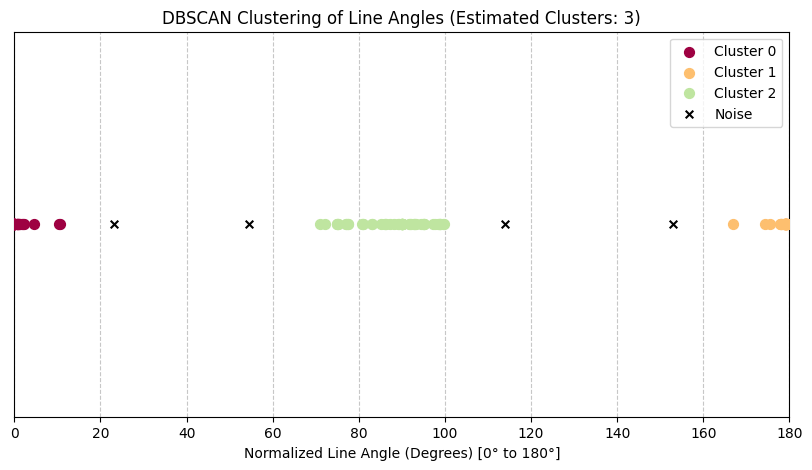

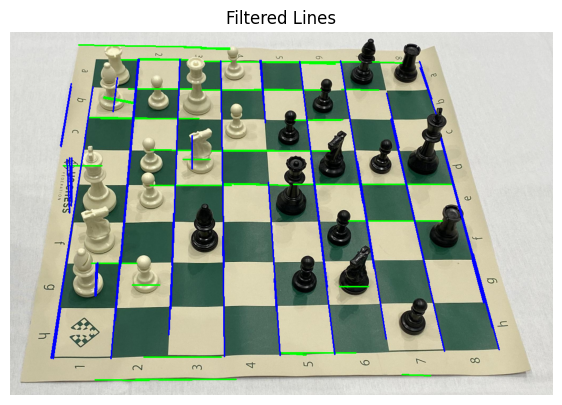

In [43]:
vertical_lines, horizontal_lines = robust_chessboard_lines(lines, num_lines=40, angle_tolerance_deg=10, min_samples=2)
show_image_debug("Filtered Lines", image, Hlines=horizontal_lines, Vlines=vertical_lines)

### Calculating Intersection And Applying First Homography

In [44]:
def compute_intersection(line1, line2):
    """
    Finds the intersection of two lines given in (x1, y1, x2, y2) format.
    Uses the cross product method (homogeneous coordinates).
    """
    x1, y1, x2, y2 = map(float, line1)
    x3, y3, x4, y4 = map(float, line2)

    L1 = np.cross([x1, y1, 1], [x2, y2, 1])
    L2 = np.cross([x3, y3, 1], [x4, y4, 1])

    intersection = np.cross(L1, L2)

    if intersection[2] == 0: return None
    
    x = intersection[0] / intersection[2]
    y = intersection[1] / intersection[2]
    
    return [x, y]

In [45]:
def get_4_points(h_lines, v_lines):
    h_lines = sorted(h_lines, key=lambda l: (l[1] + l[3]) / 2)
    v_lines = sorted(v_lines, key=lambda l: (l[0] + l[2]) / 2)

    top_line = h_lines[0]
    bottom_line = h_lines[-1]
    left_line = v_lines[0]
    right_line = v_lines[-1]
    p_tl = compute_intersection(top_line, left_line)
    p_tr = compute_intersection(top_line, right_line)
    p_br = compute_intersection(bottom_line, right_line)
    p_bl = compute_intersection(bottom_line, left_line)    
    print("--- Intersection Debug ---")
    print(f"Top-Left:     {p_tl}")
    print(f"Top-Right:    {p_tr}")
    print(f"Bottom-Right: {p_br}")
    print(f"Bottom-Left:  {p_bl}")
    src_points = np.float32([p_tl, p_tr, p_br, p_bl])
    return src_points
    
import cv2
import numpy as np

def warp_to_chessboard_plane(image, inter_points, output_size=(640, 640), 
                             pad_top=0.07, pad_bottom=0.01, pad_sides=0.05):
    """
    Warps the image to a top-down view with separate padding controls.
    
    Args:
        pad_top (float): % of height to add ABOVE the board (Crucial for back-row heads).
        pad_bottom (float): % of height to add BELOW the board.
        pad_sides (float): % of width to add to LEFT and RIGHT.
    """
    
    w, h = output_size
    
    # Calculate pixel values for padding
    px_top = h * pad_top
    px_bottom = h * pad_bottom
    px_left = w * pad_sides
    px_right = w * pad_sides 
    

    dst_points = np.float32([
        [px_left,      px_top],                 # Top-Left
        [w - px_right, px_top],                 # Top-Right
        [w - px_right, h - px_bottom],          # Bottom-Right
        [px_left,      h - px_bottom]           # Bottom-Left
    ])

    M = cv2.getPerspectiveTransform(inter_points, dst_points)
    
    warped_img = cv2.warpPerspective(image, M, output_size, borderValue=(128,128,128))
    
    return warped_img, M



--- Intersection Debug ---
Top-Left:     [np.float64(167.23719097097813), np.float64(24.659261913292728)]
Top-Right:    [np.float64(769.325772801225), np.float64(35.0400995310556)]
Bottom-Right: [np.float64(939.4998099169065), np.float64(663.6421549991853)]
Bottom-Left:  [np.float64(75.28778299000612), np.float64(655.1694880685295)]


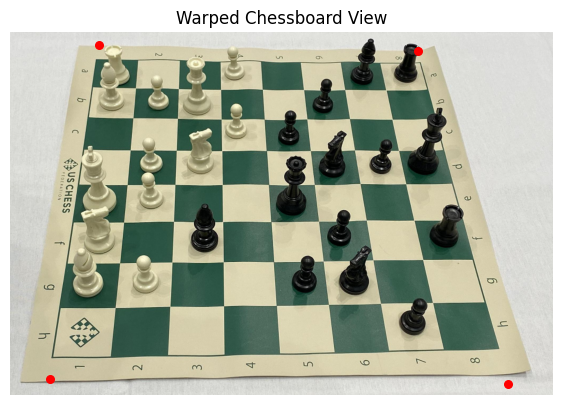

In [46]:
corner_pts = get_4_points(horizontal_lines, vertical_lines)
show_image_debug("Warped Chessboard View", image,points=corner_pts)

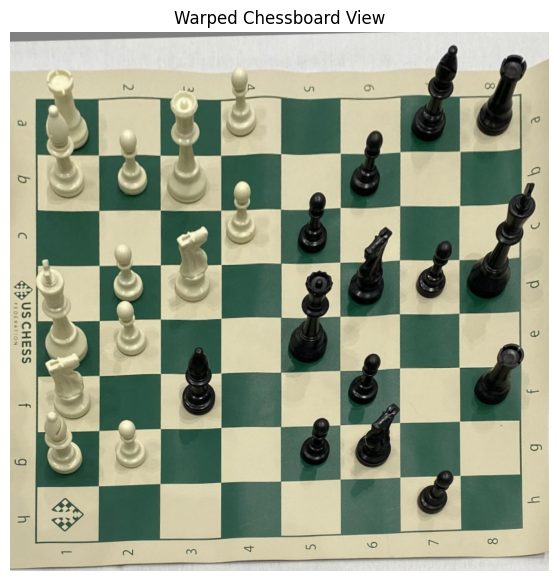

In [47]:
wrapped_image, H = warp_to_chessboard_plane(image, corner_pts, output_size=(1024, 1024), 
                                            pad_top=0.07, pad_bottom=0.01, pad_sides=0.05)
show_image_debug("Warped Chessboard View", wrapped_image)

### Second Homography

In [48]:
def split_lines_hv(lines, angle_tolerance_deg=5):
    """
    Splits lines into horizontal and vertical groups based on their angle.
    Assumes lines are in [x1, y1, x2, y2] format.
    """
    h_lines = []
    v_lines = []
    
    # Convert tolerance to radians
    tolerance_rad = np.deg2rad(angle_tolerance_deg)
    
    for line in lines:
        x1, y1, x2, y2 = line.flatten()
        
        # Calculate angle (theta) of the line segment
        angle_rad = np.arctan2(y2 - y1, x2 - x1)
        
        
        # Check for Horizontal (Angle close to 0 or pi)
        if (np.abs(angle_rad) < tolerance_rad) or (np.abs(angle_rad - np.pi) < tolerance_rad):
            h_lines.append(line)
        # Check for Vertical (Angle close to pi/2 or -pi/2)
        elif (np.abs(angle_rad - np.pi/2) < tolerance_rad) or (np.abs(angle_rad + np.pi/2) < tolerance_rad):
            v_lines.append(line)

    h_lines = np.array(h_lines, dtype=np.float32)
    v_lines = np.array(v_lines, dtype=np.float32)
    
    return h_lines, v_lines

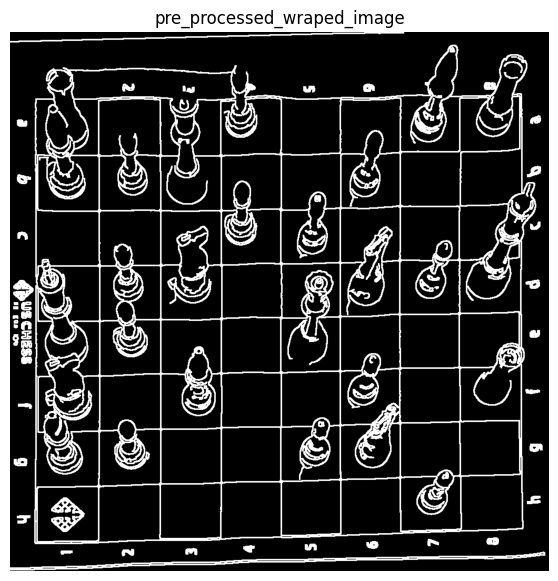

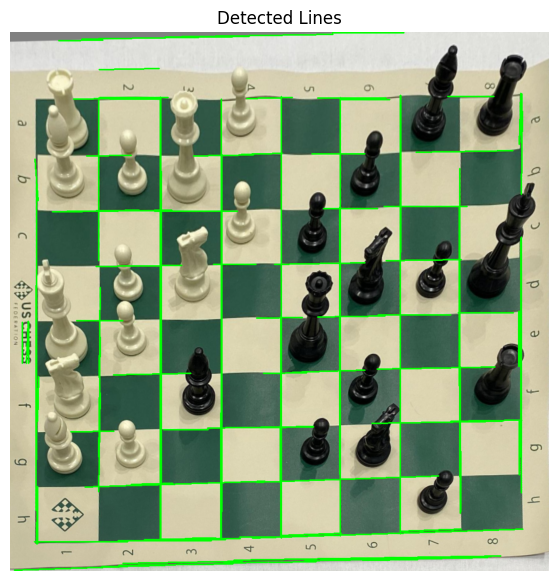

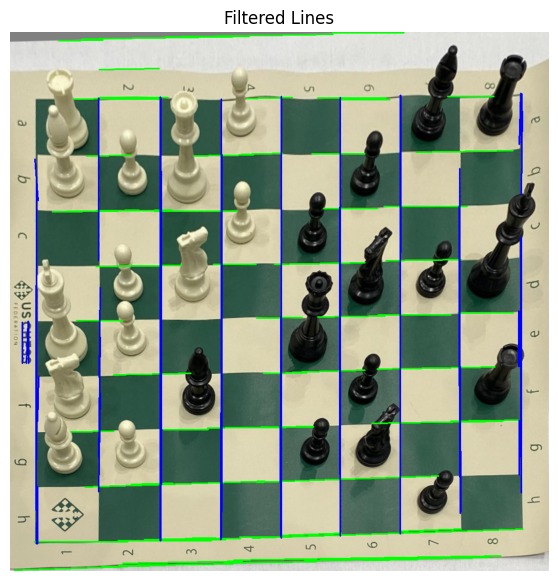

In [49]:
wrapped_image_processed = pre_processing_pipeline(wrapped_image, threshold1=10, threshold2=150)
show_image_debug("pre_processed_wraped_image", wrapped_image_processed)

wrapped_lines = detect_lines(wrapped_image_processed, hough_threshold=100, min_line_length=75, max_line_gap=3)
show_image_debug("Detected Lines", wrapped_image, Hlines=wrapped_lines)

wrapped_horizontal_lines, wrapped_vertical_lines = split_lines_hv(wrapped_lines, angle_tolerance_deg=5)
show_image_debug("Filtered Lines", wrapped_image, Hlines=wrapped_horizontal_lines, Vlines=wrapped_vertical_lines)


In [50]:
def collapse_and_average_lines(lines, dimension_index, grouping_threshold=15, num_lines=9):
    """
    Groups line segments that are close together and returns the mean position 
    for the top 'num_lines' groups.
    
    lines: The list/array of line segments (N, 4) in [x1, y1, x2, y2] format.
    dimension_index: 0 for vertical lines (checking X), 1 for horizontal lines (checking Y).
    grouping_threshold: Max pixel distance for lines to be considered the same (e.g., 15 pixels).
    num_lines: The expected final number of unique lines (must be 9 for a chessboard).
    """
    if len(lines) == 0:
        return np.array([])

    # 1. Calculate the position (P) for each line P = Average of the coordinate in the specified dimension: (coord1 + coord2) / 2
    positions = (lines[:, dimension_index] + lines[:, dimension_index + 2]) / 2
    
    # 2. Combine position with the original line for sorting
    combined = np.hstack((positions.reshape(-1, 1), lines))
    
    # 3. Sort primarily by position (X or Y)
    combined = combined[combined[:, 0].argsort()]
    
    # 4. Collapse/Cluster Lines
    final_positions = []
    current_cluster = []
    
    if len(combined) > 0:
        # Start the first cluster
        current_cluster.append(combined[0, 0])
        
        for i in range(1, len(combined)):
            current_pos = combined[i, 0]
            last_pos_in_cluster = current_cluster[-1]
            
            # If the current line is close to the last one in the cluster, add it
            if np.abs(current_pos - last_pos_in_cluster) < grouping_threshold:
                current_cluster.append(current_pos)
            else:
                # New cluster starts: Average the old cluster and save the position
                final_positions.append(np.mean(current_cluster))
                current_cluster = [current_pos]
        
        if current_cluster: final_positions.append(np.mean(current_cluster))

    if len(final_positions) != num_lines:
        print(f"Warning: Found {len(final_positions)} clusters, expected {num_lines}. Check 'grouping_threshold'.")
        

    return np.array(final_positions, dtype=np.float32)


def get_ideal_line_positions(h_lines, v_lines, threshold=15):
    """
    Wrapper function to apply clustering to both horizontal and vertical lines.
    """
    # Vertical lines: We look at the X-coordinate (index 0)
    ideal_x_positions = collapse_and_average_lines(
        v_lines, 
        dimension_index=0, 
        grouping_threshold=threshold
    )
    
    # Horizontal lines: We look at the Y-coordinate (index 1)
    ideal_y_positions = collapse_and_average_lines(
        h_lines, 
        dimension_index=1, 
        grouping_threshold=threshold
    )
    
    return ideal_x_positions, ideal_y_positions

In [51]:


def filter_redundant_lines_no_averaging(positions, grid_size=9):
    """
    Filters redundant line positions until the desired number of lines (grid_size) 
    is reached. It prioritizes the removal of lines closest to a neighbor. 
    It includes a specific tie-breaker to handle noisy edge lines, prioritizing 
    their removal when they are part of the tightest cluster.

    Args:
        positions (list or np.ndarray): A sorted list of line positions (coordinates).
        grid_size (int): The target number of lines to retain.

    Returns:
        np.ndarray: The filtered and sorted array of line positions.
    """
    positions = np.array(sorted(positions), dtype=float)
    
    if len(positions) <= grid_size:
        return positions
    
    while len(positions) > grid_size:
        
        # 1. Calculate Gaps L and R
        N = len(positions)
        max_dist = positions[-1] - positions[0]
        large_dist = max_dist * 2.0
        
        # Distance to the left neighbor (previous element)
        dist_to_left = np.insert(np.diff(positions), 0, large_dist)
        
        # Distance to the right neighbor (next element)
        dist_to_right = np.append(np.diff(positions), large_dist)

        # 2. Determine Redundancy Score (Minimum Distance to Nearest Neighbor)
        distance_to_nearest_neighbor = np.minimum(dist_to_left, dist_to_right)
        
        # Find the minimum distance (the smallest gap)
        min_dist = np.min(distance_to_nearest_neighbor)
        
        # Find all indices that are part of the tightest cluster
        indices_to_consider = np.where(distance_to_nearest_neighbor == min_dist)[0]
        
        # 3. Tie-Breaker Strategy (Prioritize Edge - Largest Gap)
        
        remove_index = -1
        
        # 3a. Check for boundary line candidates (P0 or PN-1)
        if 0 in indices_to_consider:
            remove_index = 0
        elif (N - 1) in indices_to_consider:
            remove_index = N - 1
        
        # 3b. If no boundary line was selected, use the "largest new gap" heuristic 
        if remove_index == -1:
            tied_internal_indices = indices_to_consider
            
            gap_if_removed = dist_to_left[tied_internal_indices] + dist_to_right[tied_internal_indices]

            max_gap_tied_index = np.argmax(gap_if_removed)
            
            remove_index = tied_internal_indices[max_gap_tied_index]

        # 4. Remove the line
        positions = np.delete(positions, remove_index)

    return positions








def create_drawing_lines(positions, dimension_index, image_width, image_height):
    """
    Converts a 1D array of mean positions (X or Y) into a 2D array of 
    [x1, y1, x2, y2] segments that span the image.
    """
    drawing_lines = []
    
    for pos in positions:
        pos = int(pos)
        if dimension_index == 1: 
            # Create a line from (0, Y_pos) to (Width, Y_pos)
            line_segment = [0, pos, image_width, pos]
        elif dimension_index == 0: 
            # Create a line from (X_pos, 0) to (X_pos, Height)
            line_segment = [pos, 0, pos, image_height]
        
        drawing_lines.append(line_segment)
        
    return np.array(drawing_lines, dtype=np.float32)

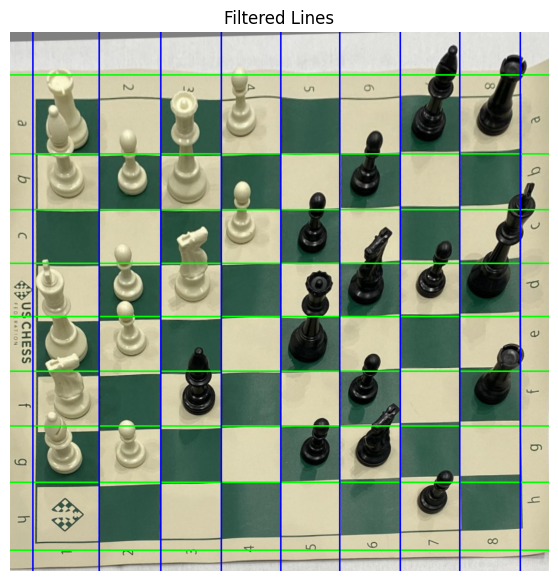

In [52]:
h, w = wrapped_image.shape[:2]

c_wrapped_horizontal_pos = collapse_and_average_lines(
    wrapped_horizontal_lines, 
    dimension_index=1, 
    grouping_threshold=60
)
c_wrapped_vertical_pos = collapse_and_average_lines(
    wrapped_vertical_lines, 
    dimension_index=0, 
    grouping_threshold=60
)

final_y_pos = filter_redundant_lines_no_averaging(c_wrapped_horizontal_pos)
final_x_pos = filter_redundant_lines_no_averaging(c_wrapped_vertical_pos)

final_h_lines = create_drawing_lines(final_y_pos, 1, w, h)
final_v_lines = create_drawing_lines(final_x_pos, 0, w, h)


show_image_debug("Filtered Lines", wrapped_image, Hlines=final_h_lines, Vlines=final_v_lines)


In [53]:
def generate_final_grid_points(final_x_pos, final_y_pos, grid_size=9):
    """
    Creates the final (9, 9, 2) grid matrix from the set of perfect X and Y coordinates.
    
    final_x_pos: 1D array of 9 unique X coordinates (vertical line positions).
    final_y_pos: 1D array of 9 unique Y coordinates (horizontal line positions).
    """
    
    if len(final_x_pos) != grid_size or len(final_y_pos) != grid_size:
        print(f"Error: Expected {grid_size} positions in each dimension, found {len(final_x_pos)} and {len(final_y_pos)}.")
        return None

    all_points = []
    
    for y in final_y_pos:
        for x in final_x_pos:
            all_points.append([x, y])
            
    final_grid_matrix = np.array(all_points, dtype=np.float32).reshape(grid_size, grid_size, 2)
    
    return final_grid_matrix

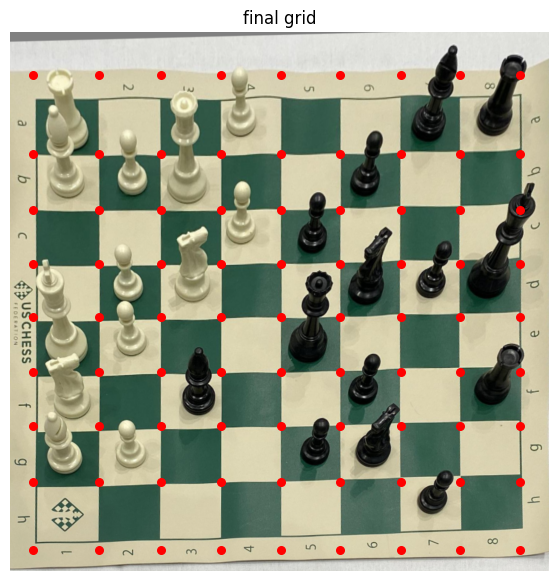

In [54]:
final_grid = generate_final_grid_points(final_x_pos,final_y_pos)
flat_points_array = final_grid.reshape(-1, 2)
show_image_debug("final grid",wrapped_image,points=flat_points_array)


## Crop Strategy

In [55]:
import numpy as np

def extract_tiles_and_pieces_dynamic(warped_image, grid_points, corner_pts,
                                     left=20, right=20, bottom=-30, 
                                     base_top=35, scale_factor=0.5): 
    """
    Extracts:
    1. tiles: STRICT floor crop (Unchanged, for occupancy check).
    2. pieces: DYNAMIC crop (Variable height to catch heads in back rows).
    """
    tiles = []
    pieces = []

    board_h, board_w = warped_image.shape[:2]
    ideal_tile_h = board_h / 8


    # We calculate how much the board is 'stretched' to decide how much extra 

    orig_w = np.linalg.norm(corner_pts[1] - corner_pts[0])
    orig_h = np.linalg.norm(corner_pts[3] - corner_pts[0])
    

    distortion_ratio = (orig_h / orig_w) * 3  
    print(distortion_ratio)
    for i in range(8):      # Row (0 is top, 7 is bottom)
        for j in range(8):  # Column
            

            p_tl = grid_points[i, j]
            p_br = grid_points[i+1, j+1]
            
            x_min = int(min(grid_points[i,j][0], grid_points[i+1,j][0]))
            x_max = int(max(grid_points[i,j+1][0], grid_points[i+1,j+1][0]))
            y_min = int(min(grid_points[i,j][1], grid_points[i,j+1][1]))
            y_max = int(max(grid_points[i+1,j][1], grid_points[i+1,j+1][1]))

   
            # TILES 
            # Crop to strictly inside the grid lines
            tile_img = warped_image[max(0, y_min - 10):min(board_h, y_max-10), 
                                    max(0, x_min):min(board_w, x_max)].copy()
            tiles.append(tile_img)


            # 2PIECES 

            row_factor = (7 - i) / 7.0 

            extra_headroom = int(base_top + (row_factor * abs(1 - distortion_ratio) * scale_factor * ideal_tile_h))
            
            # Apply offsets
            y_min_dyn = max(0, y_min - extra_headroom)

            y_max_dyn = min(board_h, y_max + bottom)
            
            current_left = left
            current_right = right
            
            # If we are on the far Left Column , add extra padding
            if j == 0:
                current_left += 15
                
            # If we are on the far Right Column , add extra padding
            if j == 7:
                current_right += 15

            x_min_dyn = max(0, x_min - current_left)
            x_max_dyn = min(board_w, x_max + current_right)

            piece_img = warped_image[y_min_dyn:y_max_dyn, x_min_dyn:x_max_dyn].copy()
            pieces.append(piece_img)

    return tiles, pieces


tiles, pieces = extract_tiles_and_pieces_dynamic(wrapped_image, final_grid, corner_pts)

3.174375


### Resize images

In [56]:

def resize_tiles(tiles, size=(64, 64)):
    """
    Resize a list of tile images to a fixed size.
    
    Parameters:
        tiles: list of numpy arrays (tile images)
        size: tuple (width, height) to resize each tile
    
    Returns:
        List of resized tiles
    """
    resized_tiles = [cv2.resize(tile, size, interpolation=cv2.INTER_AREA) for tile in tiles]
    return resized_tiles


tiles = resize_tiles(tiles, size=(227, 227))
pieces = resize_tiles(pieces, size=(227, 227))


### Load Dino and Classifiers

In [57]:
import torch
import joblib
from torchvision import transforms

# Load the DINOv2 model 

print("Loading DINOv2 model...")
dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dino.eval() 

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dino.to(DEVICE)


dino_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load saved Classifiers
print("Loading Custom Classifiers")
clf_occupancy = joblib.load('models/model_occupancy.pkl')
clf_piece = joblib.load('models/model_piece.pkl')
classes = joblib.load('models/model_classes.pkl')

print("DINOv2 + SVMs loaded.")

Loading DINOv2 model...


Using cache found in /Users/cheniour/.cache/torch/hub/facebookresearch_dinov2_main


Loading Custom Classifiers
DINOv2 + SVMs loaded.


In [58]:
from PIL import Image
from sklearn.preprocessing import normalize

def extract_features_from_list(image_list):

    batch_tensors = []
    
    for img in image_list:

        if isinstance(img, np.ndarray):
            if img.ndim == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(img)
        else:
            pil_img = img
            
        # Apply DINO transforms
        t = dino_transform(pil_img)
        batch_tensors.append(t)
        
    if not batch_tensors: return np.array([])
    
    batch_tensor = torch.stack(batch_tensors).to(DEVICE)
    
    # Run DINO
    with torch.no_grad():
        features = dino(batch_tensor).cpu().numpy()
        
    # Normalize 
    features = normalize(features, norm='l2')
    
    return features


In [59]:
import copy
import numpy as np

def apply_global_constraints(board_probs, train_classes, svm_classes, penalty_factor=0.1, promotion_threshold=0.85):
    """
    1. KINGS: Highlander Rule (Max 1).
       - Finds the best candidate.
       - AMPLIFIES it (Boost confidence) to ensure it survives.
       - Kills all others.
    2. OTHERS: Smart Rule.
       - Allows promotion if confident (>"promotion_threshold"%).
       - Penalizes ghosts if weak.
    """
    corrected_probs = copy.deepcopy(board_probs)
    
    # STRICT LOGIC FOR KINGS (Must have exactly 1)
    for king_name in ['wk', 'bk']:
        try:
            if king_name not in train_classes: continue
            name_idx = train_classes.index(king_name)
            col_idx = np.where(svm_classes == name_idx)[0][0]
            
            # Find all candidates
            candidates = []
            for i in range(64):
                probs = corrected_probs[i]
                if probs is not None:
                    # Storing 3 values: (square_index, probability, column_index)
                    candidates.append((i, probs[col_idx], col_idx))
            
            # Sort by confidence (Best first)
            candidates.sort(key=lambda x: x[1], reverse=True)
            
            if len(candidates) > 0:
                best_sq, best_prob, best_col = candidates[0]
                
                corrected_probs[best_sq][:] = 0.0      # Reset square
                corrected_probs[best_sq][best_col] = 1.0 # Force King to 100%

            # KILL THE OTHER KINGS
            for i, (square_idx, prob, col_idx_cand) in enumerate(candidates):
                if i >= 1:
                    corrected_probs[square_idx][col_idx_cand] = 0
                    total = np.sum(corrected_probs[square_idx])
                    if total > 0: corrected_probs[square_idx] /= total
                    
        except: continue

    # LOGIC FOR OTHERS
    PIECE_LIMITS = {
        'wq': 1, 'bq': 1,
        'wr': 2, 'br': 2,
        'wb': 2, 'bb': 2,
        'wn': 2, 'bn': 2,
        'wp': 8, 'bp': 8
    }

    for piece_name, limit in PIECE_LIMITS.items():
        try:
            if piece_name not in train_classes: continue
            name_idx = train_classes.index(piece_name)
            col_idx = np.where(svm_classes == name_idx)[0][0]
            
            candidates = []
            for i in range(64):
                probs = corrected_probs[i]
                if probs is not None:
                    candidates.append((i, probs[col_idx]))
            
            candidates.sort(key=lambda x: x[1], reverse=True)
            
            for i, (square_idx, prob) in enumerate(candidates):
                if i >= limit:
                    # PROMOTION CHECK (>promotion_threshold % keeps it)
                    if prob > promotion_threshold: continue

                    # PENALTY (Most likely our model is wrong )
                    corrected_probs[square_idx][col_idx] *= penalty_factor
                    total = np.sum(corrected_probs[square_idx])
                    if total > 0: corrected_probs[square_idx] /= total

        except: continue

    return corrected_probs


In [60]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def get_final_board_state(tiles, pieces, clf_occ, clf_piece, classes, ghost_threshold=0.45, debug=False):
    """
    Returns the final 8x8 board state.
    If debug=True, it VISUALIZES the board showing exactly what the AI saw 
    and how the logic fixed it (e.g., KILLED duplicate King, BOOSTED real King).
    """
    
    # Extract Features
    occ_feats = extract_features_from_list(tiles)
    piece_feats = extract_features_from_list(pieces)
    
    # Initial Predictions 
    occupancy_states = []
    occ_confidences = [] # For debug display
    raw_board_probs = [None] * 64
    
    for i in range(64):
        # Occupancy Check
        feat_occ = occ_feats[i].reshape(1, -1)
        occ_prob = clf_occ.predict_proba(feat_occ)[0]
        
        conf = occ_prob[1]
        occ_confidences.append(conf)
        
        is_occupied = conf > 0.7
        occupancy_states.append(is_occupied)
        
        # Get Piece Probabilities (only if occupied)
        if is_occupied:
            feat_piece = piece_feats[i].reshape(1, -1)
            raw_board_probs[i] = clf_piece.predict_proba(feat_piece)[0]
            
    # Apply Global Logic 
    # raw_board_probs = BEFORE 
    # final_probs     = AFTER applying logic 
    final_probs = apply_global_constraints(raw_board_probs, classes, clf_piece.classes_)
    
    # DEBUG VISUALIZATION 
    if debug:
        print(" DEBUG MODE: Showing Logic Impact (Raw SVM vs. Final Logic)")
        plt.figure(figsize=(20, 20))
        
        for i in range(64):
            ax = plt.subplot(8, 8, i + 1)
            plt.axis('off')
            
            # Show Image
            img = pieces[i]
            if isinstance(img, np.ndarray) and img.ndim == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img)
            
            # Prepare Label Logic
            occ_p = occ_confidences[i]
            
            if not occupancy_states[i]:
                text = f"Empty\n({1-occ_p:.0%})"
                color = 'gray'
            else:
                def get_data(probs):
                    if probs is None: return "Err", 0.0
                    idx = np.argmax(probs)
                    val = clf_piece.classes_[idx]
                    name = classes[val] if isinstance(val, (int, np.integer)) else str(val)
                    # Shorten name: 'white_knight' -> 'WN'
                    s = name.lower().replace("white_", "W").replace("black_", "B")
                    s = s.replace("knight", "N").replace("pawn", "P").replace("king", "K").replace("queen", "Q").upper()
                    return s, probs[idx]

                raw_name, raw_score = get_data(raw_board_probs[i])
                final_name, final_score = get_data(final_probs[i])
                
                text = f"Occ: {occ_p:.0%}\n"
                
                # Compare Before vs After
                if raw_name == final_name and abs(raw_score - final_score) < 0.05:
                    # Normal (No Logic Change)
                    text += f"{final_name}: {final_score:.0%}"
                    color = 'black'
                    
                    if final_score < ghost_threshold:
                        text += "\n(GHOST)"
                        color = 'orange'
                else:
                    # logic changed something
                    text += f"Raw: {raw_name} {raw_score:.0%}\n"
                    text += f"Fix: {final_name} {final_score:.0%}"
                    
                    if final_score < 0.1:
                        text += "\n(KILLED)" 
                        color = 'red'
                    elif final_score > raw_score:
                        text += "\n(BOOST)"  
                        color = 'green'
                    else:
                        text += "\n(PENALTY)" 
                        color = 'blue'
            
            # Add text box on image
            plt.title(text, color=color, fontsize=8, fontweight='bold', y=0.85, 
                      bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
            
        plt.tight_layout()
        plt.show()
        print(" Debug visualization complete.")

    #  Final Decision Generation 
    board_state_list = []
    
    for i in range(64):
        if not occupancy_states[i]:
            board_state_list.append("empty")
        else:
            probs = final_probs[i]
            top_idx = np.argmax(probs)
            top_prob = probs[top_idx]
            
            # map index to Class name
            class_idx_in_train = clf_piece.classes_[top_idx]
            class_name = classes[class_idx_in_train]
            
            if top_prob < ghost_threshold:
                board_state_list.append("empty")
            else:
                board_state_list.append(class_name)
                
    return board_state_list

In [61]:
def board_to_fen(board_list):
    """
    Converts  ['bk', 'empty', 'wp'...] into a FEN string.
    Example output: "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR"
    """
    # Upper case = White, Lower case = Black
    # N = Knight, K = King, etc.
    fen_map = {
        "empty": None,
        
        "wk": "K", "wq": "Q", "wr": "R", "wb": "B", "wn": "N", "wp": "P",
        "bk": "k", "bq": "q", "br": "r", "bb": "b", "bn": "n", "bp": "p"
    }
    
    fen_rows = []
    
    for row in range(8):
        empty_count = 0
        row_str = ""
        
        for col in range(8):
            idx = row * 8 + col
            label = board_list[idx]
            
            char = fen_map.get(label, "?")
            
            if char is None:
                empty_count += 1
            else:
                if empty_count > 0:
                    row_str += str(empty_count)
                    empty_count = 0
                row_str += char
                
        if empty_count > 0:
            row_str += str(empty_count)
            
        fen_rows.append(row_str)
        

    return "/".join(fen_rows) + " w - - 0 1"


In [62]:
import chess
import chess.svg
from IPython.display import display, SVG

def show_digital_board(fen):
    board = chess.Board(fen)

    display(SVG(chess.svg.board(board=board, size=400)))
    
    if board.is_valid():
        print(" Board is valid state")
    else:
        print(f" Invalid Board: {board.status()}")


In [63]:
import numpy as np
import chess

def fix_board_orientation(board_list):
    """
    Tries all 4 rotations (0, 90, 180, 270) and picks the one 
    that creates the most 'Chess-like' position.
    """
    best_fen = None
    best_list = board_list
    best_score = -float('inf')
    best_angle = 0
    
    # We will score each rotation. 
    # High Score = White at Bottom (Rows 6-7), Black at Top (Rows 0-1)
    
    for k in range(4): # 0, 1, 2, 3 (representing 0, 90, 180, 270 degrees)
        # Rotate the list 
        arr = np.array(board_list).reshape(8, 8)
        rotated_arr = np.rot90(arr, k=k) # Rotates 90 degrees 'k' times
        current_list = rotated_arr.flatten().tolist()
        
        #  Generate FEN
        fen = board_to_fen(current_list)
        
        #  Check Validity using Chess Library
        board = chess.Board(fen)
        if not board.is_valid():
            continue # skip impossible boards

        # 4. Calculate "Standard View Score"
        # We want White to have HIGH indices (Bottom of list)
        # We want Black to have LOW indices (Top of list)
        score = 0
        for i, piece in enumerate(current_list):
            if "w" in piece.lower():
                score += i # White wants to be at the bottom (high index)
            elif "b" in piece.lower() :
                score -= i # Black wants to be at the top (low index)
        
        # Keep the best one
        if score > best_score:
            best_score = score
            best_fen = fen
            best_list = current_list
            best_angle = k * 90

    if best_fen:
        print(f" Auto-Rotation: Rotated board by {best_angle} to fix perspective")
        return best_list
    else:
        print(" No valid chess rotation found. Using original")
        return board_list

In [ ]:
print(" Classifying pieces...")
final_classes = get_final_board_state(
    tiles, pieces, clf_occupancy, clf_piece, 
    classes, ghost_threshold=0.45, debug=True
 )

Checking orientation...
 No valid chess rotation found. Using original

📋 FEN: 1KR1n3/PPPPN1BB/2N1B1B1/4BB2/4p3/1pPp1npp/pbp5/1kr1pb1r w - - 0 1


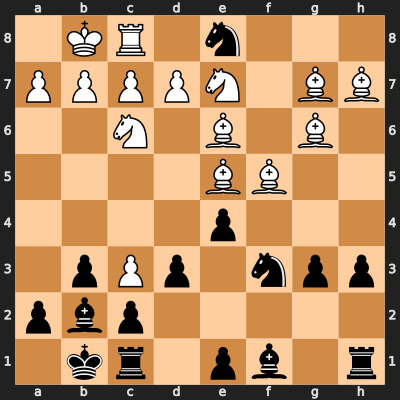

 Invalid Board: 32


In [ ]:
print("Checking orientation...")
final_classes = fix_board_orientation(final_classes)


# DIGITIZATION
fen = board_to_fen(final_classes)
print(f"\n📋 FEN: {fen}")

show_digital_board(fen)

In [ ]:
import subprocess
import os
import chess

def get_best_move(fen_string, stockfish_path, time_limit=1.0):
    


    if not os.path.exists(stockfish_path):
        print(f" Engine not found at {stockfish_path}")
        return None

    commands = f"position fen {fen_string}\ngo movetime {int(time_limit*1000)}\nquit\n" 
    try:

        process = subprocess.Popen(
            stockfish_path,
            universal_newlines=True,
            stdin=subprocess.PIPE,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE
        )
        
        # Send commands and wait for output
        stdout, _ = process.communicate(input=commands)
        
        best_move = None  
        # Parse Output
        for line in stdout.split("\n"):
            if line.startswith("bestmove"):
                best_move = line.split()[1]
        
        # Display Results
        board = chess.Board(fen_string)
        print(f"Turn: {'White' if board.turn == chess.WHITE else 'Black'} :")
        
        if best_move:
            try:
                return board.san(chess.Move.from_uci(best_move))
            except:
                return best_move
        return None

    except Exception as e:
        print(f" Error: {e}")
        return None


MY_STOCKFISH = r"stockfish\stockfish-windows-x86-64-avx2.exe"
print(get_best_move(fen, MY_STOCKFISH))

 Engine not found at stockfish\stockfish-windows-x86-64-avx2.exe
None
